

## Compile-Once-and-Relabel Solution for Topology-Dependent Structural Asymmetry in Compiled Equivariant Quantum Neural Networks

by: H. Ugail and N. Howard

Compiling equivariant quantum neural networks can break their symmetry at the structural level: vertex-permutation-related sparse-graph inputs to the Skolik ansatz produce substantially different compiled circuits on IBM Heron's Fez. We classify ansätze by where the input enters and fix the affected case via compile-once-and-relabel.

### How to use this notebook

Run the cells top-to-bottom. With `QUICK_MODE = True` (the default) the
notebook completes in roughly five minutes on Colab CPU and reproduces all
qualitative results at moderate statistics (K=10–15 seeds per configuration).
With `QUICK_MODE = False` the notebook uses K=50 seeds for the Fez $n=12$
mechanism analysis and K=25 seeds for the scaling sweeps, matching the paper's
headline statistics exactly; runtime is approximately twenty minutes.


### Structure

1. Configuration, imports, and shared utilities
2. Case study: Skolik ansatz ($S_n$, topology-input)
3. Case study: Dong ansatz ($\mathbb{Z}_2 \times \mathbb{Z}_2$, parameter-input)
4. Case study: West ansatz ($\mathbb{Z}_2$ reflection, parameter-input)
5. Case study: Chang ansatz ($p4m$, parameter-input)
6. Mechanism analysis: automorphism hypothesis and layout divergence
7. Mitigation verification: matched-layout and compile-once-and-relabel
8. Figure generation
9. Reproducibility summary table

Every number quoted in the paper is traceable to a specific cell; Section 9
collects them into an indexed table.

### Dependencies

Standard scientific Python stack plus `qiskit >= 2.0` and `qiskit-ibm-runtime`
for the `FakeFez` and `FakeTorino` targets. Install with:

```
pip install qiskit qiskit-ibm-runtime
```


## 1. Configuration, imports, and shared utilities

In [1]:
# Colab installation (uncomment if running fresh):
!pip install -q qiskit qiskit-ibm-runtime

# =========================================================================
# User-facing configuration
# =========================================================================
QUICK_MODE = False             # True: ~5 min runtime; False: ~20 min for paper stats
SAVE_PAPER_FIGURES = False     # True: save 300 DPI PNGs alongside in-notebook display
FIGURE_OUTPUT_DIR = "./paper_figures"

MASTER_SEED = 2026             # Fixed for reproducibility

# Skolik graph generation
P_EDGE = 0.5                   # Erdős–Rényi edge probability G(n, p)
ENSURE_CONNECTED = True        # Reject draws that yield a disconnected graph
                               # (so every qubit is touched by at least one R_ZZ gate)

# Derived settings
if QUICK_MODE:
    K_SCALING = 10             # seeds per (backend, n) in scaling sweep
    K_MECHANISM = 20           # seeds for Fez n=12 mechanism analysis
    N_RANGE = [4, 6, 8, 10, 12, 14, 16]
else:
    K_SCALING = 25
    K_MECHANISM = 50
    N_RANGE = [4, 6, 8, 10, 12, 14, 16]

print(f"Configuration:")
print(f"  QUICK_MODE       = {QUICK_MODE}")
print(f"  K_SCALING        = {K_SCALING}")
print(f"  K_MECHANISM      = {K_MECHANISM}")
print(f"  N_RANGE          = {N_RANGE}")
print(f"  MASTER_SEED      = {MASTER_SEED}")
print(f"  P_EDGE           = {P_EDGE}")
print(f"  ENSURE_CONNECTED = {ENSURE_CONNECTED}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.8 MB/s eta 0:00:00
Configuration:
  QUICK_MODE       = False
  K_SCALING        = 25
  K_MECHANISM      = 50
  N_RANGE          = [4, 6, 8, 10, 12, 14, 16]
  MASTER_SEED      = 2026
  P_EDGE           = 0.5
  ENSURE_CONNECTED = True


In [2]:
# =========================================================================
# Imports
# =========================================================================
import os
import time
import warnings
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, Statevector
from qiskit.transpiler import CouplingMap
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino

import qiskit

warnings.filterwarnings("ignore", category=DeprecationWarning)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print(f"Qiskit version: {qiskit.__version__}")
print(f"(Paper was developed against Qiskit 2.4.0.)")

# Global results dictionary -- every cell writes its key findings here so the
# final reproducibility table can assemble them.
results = {}

# Create figure output directory if needed
if SAVE_PAPER_FIGURES:
    os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Qiskit version: 2.4.1
(Paper was developed against Qiskit 2.4.0.)


In [3]:
# =========================================================================
# Shared utilities used throughout the notebook
# =========================================================================

def reduced_cmap(backend, n, start=0):
    '''Return a list of [a, b] edges for the BFS-reduced subgraph of
    the backend's coupling map containing `n` qubits, starting from `start`.'''
    edges = list(backend.coupling_map.get_edges())
    adj = {}
    for (a, b) in edges:
        adj.setdefault(a, set()).add(b); adj.setdefault(b, set()).add(a)
    visited, seen, q = [], {start}, deque([start])
    while q and len(visited) < n:
        x = q.popleft(); visited.append(x)
        for nb in sorted(adj.get(x, [])):
            if nb not in seen: seen.add(nb); q.append(nb)
    idx = {q_: i for i, q_ in enumerate(visited[:n])}
    return [[idx[a], idx[b]] for (a, b) in edges if a in idx and b in idx]


def cz_count(qc):
    '''Count of CZ gates in a compiled circuit (IBM Heron native entangler).'''
    return qc.count_ops().get('cz', 0)


def structural_metrics(t_A, t_B):
    '''Compute CZ count difference, relative CZ asymmetry, and depth
    difference between two compiled circuits.'''
    cz_A, cz_B = cz_count(t_A), cz_count(t_B)
    cz_diff = abs(cz_A - cz_B)
    cz_mean = 0.5 * (cz_A + cz_B)
    cz_rel = cz_diff / cz_mean if cz_mean > 0 else 0.0
    return {
        'cz_A': cz_A, 'cz_B': cz_B,
        'cz_diff': cz_diff, 'cz_rel': cz_rel,
        'depth_A': t_A.depth(), 'depth_B': t_B.depth(),
        'depth_diff': abs(t_A.depth() - t_B.depth()),
    }


def permutation_unitary(pi, n):
    '''Qiskit little-endian permutation unitary for virtual qubit permutation pi.
    Used for layout-corrected unitary equivariance checks.'''
    dim = 2**n
    U = np.zeros((dim, dim), dtype=complex)
    for idx in range(dim):
        bits = [(idx >> q) & 1 for q in range(n)]
        new_bits = [0] * n
        for q in range(n):
            new_bits[pi[q]] = bits[q]
        new_idx = sum(b << q for q, b in enumerate(new_bits))
        U[new_idx, idx] = 1.0
    return U


def inverse_permutation(pi):
    '''Return pi^{-1}.'''
    pi_inv = [0] * len(pi)
    for i, j in enumerate(pi):
        pi_inv[j] = i
    return pi_inv


def compile_pair(qc_A, qc_B, backend=None, coupling_map=None,
                  basis_gates=None, opt_level=3, seed_transpiler=0):
    '''Transpile two circuits under identical options; return (t_A, t_B).
    This is the `Comp` operator of the paper.'''
    kwargs = dict(optimization_level=opt_level, seed_transpiler=seed_transpiler)
    if backend is not None:
        kwargs['backend'] = backend
    if coupling_map is not None:
        kwargs['coupling_map'] = coupling_map
    if basis_gates is not None:
        kwargs['basis_gates'] = basis_gates
    return transpile(qc_A, **kwargs), transpile(qc_B, **kwargs)


# Initialise backends used throughout the notebook
fb_fez = FakeFez()
fb_torino = FakeTorino()
print("Backends loaded:")
print(f"  FakeFez   (Heron r2):  {fb_fez.num_qubits} qubits")
print(f"  FakeTorino (Heron r1): {fb_torino.num_qubits} qubits")

Backends loaded:
  FakeFez   (Heron r2):  156 qubits
  FakeTorino (Heron r1): 133 qubits


## 2. Skolik ansatz ($S_n$, topology-input)

The Skolik equivariant quantum circuit~[1] acts on a weighted graph
$G = (V, E, w)$ with $n$ vertices via
$$
U(G;\beta,\gamma) = \prod_{\ell=1}^{L}
\exp(-i\beta_\ell \sum_{i} X_i) \cdot
\exp(-i\gamma_\ell \sum_{(i,j) \in E} w_{ij}\, Z_i Z_j).
$$
The $R_{ZZ}$ gates appear on the edges of $G$. Under a node permutation $\pi \in S_n$, the edge set changes (different
qubit pairs receive $R_{ZZ}$ gates), so the gate-topology changes and the
ansatz is **topology-input** in the paper's taxonomy. The experiments
below sample sparse weighted graphs from $G(n, p)$ with `P_EDGE` set in
the configuration cell, conditioned on connectedness, and use
`canonicalize_edges` after permutation so that the only structural
difference seen by the transpiler is the underlying edge set.

[1] Skolik et al., npj Quantum Information 9, 47 (2023).

In [4]:
def skolik_eqc(n, edges, beta, gamma):
    '''Build a single-layer Skolik equivariant quantum circuit.
    edges: list of (i, j, weight) tuples.'''
    qc = QuantumCircuit(n, name="Skolik")
    for (i, j, w) in edges:
        qc.rzz(2.0 * gamma * float(w), i, j)
    for q in range(n):
        qc.rx(2.0 * beta, q)
    return qc


def _is_connected(n, edges):
    '''Test whether a graph on n vertices with the given edge list is connected.'''
    if n <= 1:
        return True
    adj = {i: [] for i in range(n)}
    for (i, j, _) in edges:
        adj[i].append(j); adj[j].append(i)
    seen = {0}; stack = [0]
    while stack:
        v = stack.pop()
        for u in adj[v]:
            if u not in seen:
                seen.add(u); stack.append(u)
    return len(seen) == n


def random_erdos_renyi_graph(n, p, rng, w_lo=0.1, w_hi=1.5,
                              ensure_connected=True, max_attempts=200):
    '''Random weighted Erdős--Rényi graph G(n, p).

    Each unordered pair (i, j) with i < j is included independently with
    probability p, and present edges receive a weight w_ij ~ U(w_lo, w_hi).
    Absent edges are omitted from the circuit rather than being represented
    by zero-angle R_ZZ gates.

    If ensure_connected is True (default), the draw is rejection-sampled
    until the resulting graph is connected, so that every qubit is touched
    by at least one R_ZZ gate.'''
    for _ in range(max_attempts):
        edges = [(i, j, float(rng.uniform(w_lo, w_hi)))
                 for i in range(n) for j in range(i + 1, n)
                 if rng.random() < p]
        if not ensure_connected or _is_connected(n, edges):
            return edges
    raise RuntimeError(
        f"Could not draw a connected G(n={n}, p={p}) within {max_attempts} "
        f"attempts; increase p or disable ensure_connected.")


def random_complete_graph(n, rng, w_lo=0.1, w_hi=1.5):
    '''Random weighted complete graph on n vertices (kept for back-compat;
    no longer used for the headline Skolik experiments).'''
    return [(i, j, float(rng.uniform(w_lo, w_hi)))
            for i in range(n) for j in range(i + 1, n)]


def random_permutation(n, rng):
    '''Random permutation of [0..n-1].'''
    pi = list(range(n))
    rng.shuffle(pi)
    return pi


def permute_edges(edges, pi):
    '''Apply vertex permutation pi to an edge list.

    The output list inherits the source ordering and the per-edge tuple
    orientation of the input; call canonicalize_edges() afterwards to
    neutralise gate-order and tuple-orientation confounds.'''
    return [(pi[i], pi[j], w) for (i, j, w) in edges]


def canonicalize_edges(edges):
    '''Put each edge in (min, max, w) form and sort lexicographically.

    Applied to both U(G) and U(pi(G)), this leaves the gate-topology
    depending only on the underlying edge set, so any structural
    asymmetry observed at the compiled level reflects a genuine change
    in the qubit pairs hosting R_ZZ gates rather than a difference in
    the order in which commuting gates are presented to the transpiler.'''
    canon = [(min(i, j), max(i, j), w) for (i, j, w) in edges]
    canon.sort(key=lambda e: (e[0], e[1]))
    return canon


# Paper's hyperparameter choices (see Skolik paper for typical ranges)
BETA, GAMMA = 0.31, 0.42


### 2.1. Template-level equivariance check

The Skolik ansatz satisfies the exact unitary identity
$U(\pi(G);\beta,\gamma) = P_\pi\, U(G;\beta,\gamma)\, P_\pi^\dagger$
where $P_\pi$ is the qubit-permutation unitary. We verify this
numerically at $n=6$ (the largest size at which we can materialise
the full $64 \times 64$ unitary without memory pressure).

In [5]:
n_template = 6
rng_tmpl = np.random.default_rng(MASTER_SEED)
edges_tmpl = canonicalize_edges(
    random_erdos_renyi_graph(n_template, P_EDGE, rng_tmpl,
                              ensure_connected=ENSURE_CONNECTED))
pi_tmpl = random_permutation(n_template, rng_tmpl)
edges_pi_tmpl = canonicalize_edges(permute_edges(edges_tmpl, pi_tmpl))

U_G = np.asarray(Operator.from_circuit(
    skolik_eqc(n_template, edges_tmpl, BETA, GAMMA)).data)
U_piG = np.asarray(Operator.from_circuit(
    skolik_eqc(n_template, edges_pi_tmpl, BETA, GAMMA)).data)

P = permutation_unitary(pi_tmpl, n_template)
target = P @ U_G @ P.conj().T
residual_skolik_template = np.linalg.norm(target - U_piG, 'fro') / np.linalg.norm(U_G, 'fro')

print(f"Skolik template-level equivariance at n={n_template}:")
print(f"  Graph: G(n={n_template}, p={P_EDGE})  |E| = {len(edges_tmpl)}, |E(pi(G))| = {len(edges_pi_tmpl)}")
print(f"  ||P U(G) P^dag - U(pi(G))||_F / ||U(G)||_F = {residual_skolik_template:.3e}")
print(f"  Template equivariance holds to machine precision.")

results['skolik_template_residual_n6'] = residual_skolik_template


Skolik template-level equivariance at n=6:
  Graph: G(n=6, p=0.5)  |E| = 8, |E(pi(G))| = 8
  ||P U(G) P^dag - U(pi(G))||_F / ||U(G)||_F = 2.200e-16
  Template equivariance holds to machine precision.


### 2.2. Structural sweep on FakeFez and FakeTorino (full-device)

For each $n \in \{4, 6, 8, 10, 12, 14, 16\}$ we compile $U(G)$ and
$U(\pi(G))$ for $K_{\text{scaling}}$ random (graph, permutation) pairs
on both the FakeFez (Heron r2) and FakeTorino (Heron r1) full-device
coupling maps and record the CZ asymmetry. This produces Panel B of
Figure 1.

In [6]:
skolik_records = []
t0 = time.time()

for backend_name, backend in [('FakeFez', fb_fez), ('FakeTorino', fb_torino)]:
    for n in N_RANGE:
        for seed in range(K_SCALING):
            rng = np.random.default_rng(MASTER_SEED + 1000 * seed + n)
            edges = canonicalize_edges(
                random_erdos_renyi_graph(n, P_EDGE, rng,
                                          ensure_connected=ENSURE_CONNECTED))
            pi = random_permutation(n, rng)
            edges_pi = canonicalize_edges(permute_edges(edges, pi))

            qc_G = skolik_eqc(n, edges, BETA, GAMMA)
            qc_piG = skolik_eqc(n, edges_pi, BETA, GAMMA)

            t_G, t_piG = compile_pair(qc_G, qc_piG, backend=backend)
            m = structural_metrics(t_G, t_piG)
            m.update({'backend': backend_name, 'n': n, 'seed': seed,
                       'n_edges': len(edges)})
            skolik_records.append(m)

print(f"Skolik scaling sweep: {time.time()-t0:.1f}s  ({len(skolik_records)} pairs)")

skolik_df = pd.DataFrame(skolik_records)
skolik_scaling = skolik_df.groupby(['backend', 'n']).agg(
    cz_rel_mean=('cz_rel', 'mean'),
    cz_rel_sem=('cz_rel', lambda x: x.std() / np.sqrt(len(x))),
    cz_rel_max=('cz_rel', 'max'),
    cz_diff_mean=('cz_diff', 'mean'),
    cz_G_mean=('cz_A', 'mean'),
    n_edges_mean=('n_edges', 'mean'),
).reset_index()

print("\nSkolik structural asymmetry (full-device, opt_level=3, sparse G(n, p)):")
print(skolik_scaling.to_string(index=False, float_format=lambda x: f"{x:7.3f}"))

results['skolik_scaling_df'] = skolik_scaling


Skolik scaling sweep: 70.4s  (350 pairs)

Skolik structural asymmetry (full-device, opt_level=3, sparse G(n, p)):
   backend  n  cz_rel_mean  cz_rel_sem  cz_rel_max  cz_diff_mean  cz_G_mean  n_edges_mean
   FakeFez  4        0.010       0.007       0.167         0.120      9.280         3.760
   FakeFez  6        0.083       0.015       0.222         2.120     25.440         8.400
   FakeFez  8        0.073       0.015       0.261         3.200     46.720        14.320
   FakeFez 10        0.089       0.012       0.247         7.920     87.360        22.400
   FakeFez 12        0.063       0.010       0.204         9.160    146.840        34.120
   FakeFez 14        0.063       0.008       0.143        13.280    212.880        44.920
   FakeFez 16        0.066       0.010       0.200        19.880    300.320        58.200
FakeTorino  4        0.015       0.010       0.207         0.200      9.280         3.760
FakeTorino  6        0.070       0.013       0.192         1.680     24.840 

### 2.3. Fez $n=12$ focus

The $n=12$ point on FakeFez is the paper's headline case study. We
rerun it at higher seed count ($K_{\text{mechanism}}$) for tighter
confidence bounds and record per-seed layout information for the
mechanism analysis of Section 6.

In [7]:
n_focus = 12
fez12_records = []
t0 = time.time()

for seed in range(K_MECHANISM):
    rng = np.random.default_rng(MASTER_SEED + 1000 * seed + n_focus)
    edges = canonicalize_edges(
        random_erdos_renyi_graph(n_focus, P_EDGE, rng,
                                  ensure_connected=ENSURE_CONNECTED))
    pi = random_permutation(n_focus, rng)
    edges_pi = canonicalize_edges(permute_edges(edges, pi))

    qc_G = skolik_eqc(n_focus, edges, BETA, GAMMA)
    qc_piG = skolik_eqc(n_focus, edges_pi, BETA, GAMMA)

    t_G, t_piG = compile_pair(qc_G, qc_piG, backend=fb_fez)

    # Extract initial layouts for mechanism analysis (Section 6)
    layout_G = (list(t_G.layout.initial_index_layout(filter_ancillas=True))
                 if t_G.layout else None)
    layout_piG = (list(t_piG.layout.initial_index_layout(filter_ancillas=True))
                   if t_piG.layout else None)
    overlap = (len(set(layout_G) & set(layout_piG)) / len(layout_G)
                if layout_G and layout_piG else np.nan)

    m = structural_metrics(t_G, t_piG)
    m.update({'seed': seed, 'pi': pi, 'n_edges': len(edges),
              'layout_G': layout_G, 'layout_piG': layout_piG,
              'layout_overlap': overlap})
    fez12_records.append(m)

print(f"Fez n=12 sweep: {time.time()-t0:.1f}s  ({len(fez12_records)} seeds)")

fez12_df = pd.DataFrame(fez12_records)
fez12_mean_rel = fez12_df['cz_rel'].mean()
fez12_max_rel = fez12_df['cz_rel'].max()
fez12_min_rel = fez12_df['cz_rel'].min()
fez12_mean_diff = fez12_df['cz_diff'].mean()
fez12_sem_diff = fez12_df['cz_diff'].std() / np.sqrt(len(fez12_df))
fez12_cz_G_mean = fez12_df['cz_A'].mean()
fez12_edges_mean = fez12_df['n_edges'].mean()

print(f"\nFez n=12 (K={K_MECHANISM}, sparse G(n={n_focus}, p={P_EDGE})):")
print(f"  Mean |E|                = {fez12_edges_mean:.1f} edges per graph")
print(f"  Mean cz(G)              = {fez12_cz_G_mean:.1f}")
print(f"  Mean cz_diff            = {fez12_mean_diff:.1f} +/- {fez12_sem_diff:.2f} (SEM)")
print(f"  Mean relative asymmetry = {fez12_mean_rel*100:.1f}%")
print(f"  Worst-case asymmetry    = {fez12_max_rel*100:.1f}%")
print(f"  Best-case asymmetry     = {fez12_min_rel*100:.1f}%")

results['fez12_mean_rel'] = fez12_mean_rel
results['fez12_max_rel'] = fez12_max_rel
results['fez12_min_rel'] = fez12_min_rel
results['fez12_mean_diff'] = fez12_mean_diff
results['fez12_sem_diff'] = fez12_sem_diff
results['fez12_cz_G_mean'] = fez12_cz_G_mean
results['fez12_edges_mean'] = fez12_edges_mean


Fez n=12 sweep: 9.9s  (50 seeds)

Fez n=12 (K=50, sparse G(n=12, p=0.5)):
  Mean |E|                = 33.4 edges per graph
  Mean cz(G)              = 147.0
  Mean cz_diff            = 10.5 +/- 1.19 (SEM)
  Mean relative asymmetry = 7.3%
  Worst-case asymmetry    = 22.5%
  Best-case asymmetry     = 0.0%


## 3. Dong ansatz ($\mathbb{Z}_2 \times \mathbb{Z}_2$, parameter-input)

Dong et al.~[2] use a 2-qubit ansatz with angle embedding:
$$
U(x_1, x_2;\theta) = \prod_{\ell} R_{ZZ}(\theta_{2,\ell}) \cdot
[R_X(\theta_{1,\ell}) \otimes R_X(\theta_{1,\ell})] \cdot
[R_Z(x_1) \otimes R_Z(x_2)].
$$
The $\mathbb{Z}_2 \times \mathbb{Z}_2$ symmetry is generated by the
diagonal reflection $(x_1, x_2) \to (x_2, x_1)$ and the anti-diagonal
reflection $(x_1, x_2) \to (-x_2, -x_1)$. Both act on the input by
changing only the arguments of the $R_Z$ gates; the gate structure is
fixed. The ansatz is **parameter-input**.

[2] Dong et al., Axioms 13, 188 (2024).

In [8]:
def dong_circuit(x1, x2, thetas):
    '''Dong Z_2 x Z_2 equivariant circuit.
    thetas: list of (theta_1_l, theta_2_l) per layer.'''
    qc = QuantumCircuit(2, name="Dong")
    for (t1, t2) in thetas:
        qc.rz(x1, 0); qc.rz(x2, 1)
        qc.rx(t1, 0); qc.rx(t1, 1)
        qc.rzz(t2, 0, 1)
    return qc


# Standard 2-qubit symmetry operators (Qiskit little-endian |q_1 q_0>)
SWAP2 = np.array([[1,0,0,0], [0,0,1,0], [0,1,0,0], [0,0,0,1]], dtype=complex)
XX2 = np.kron(np.array([[0,1],[1,0]]), np.array([[0,1],[1,0]])).astype(complex)

### 3.1. Template-level equivariance check

We verify the correct unitary generators for the two $\mathbb{Z}_2$
reflections. The paper's $U_{g_r} = X \otimes X$ is observable-level only;
at the unitary level it gives $U(-x_1, -x_2)$, not $U(-x_2, -x_1)$.
The correct unitary generator for the anti-diagonal reflection is
$\mathrm{SWAP} \cdot (X \otimes X)$.

In [9]:
rng_d = np.random.default_rng(MASTER_SEED)
thetas_d = [(float(rng_d.uniform(0, 2*np.pi)), float(rng_d.uniform(0, 2*np.pi)))
             for _ in range(5)]
x1_d, x2_d = 0.37, -0.81

U_x = np.asarray(Operator.from_circuit(dong_circuit(x1_d, x2_d, thetas_d)).data)
U_sx = np.asarray(Operator.from_circuit(dong_circuit(x2_d, x1_d, thetas_d)).data)
U_gx = np.asarray(Operator.from_circuit(dong_circuit(-x2_d, -x1_d, thetas_d)).data)
U_negxx = np.asarray(Operator.from_circuit(dong_circuit(-x1_d, -x2_d, thetas_d)).data)

# (a) SWAP equivariance for the diagonal reflection
r_swap = np.linalg.norm(SWAP2 @ U_x @ SWAP2.conj().T - U_sx, 'fro')
# (b) X⊗X conjugation gives pointwise negation U(-x_1, -x_2), not U(-x_2, -x_1)
r_xx_neg = np.linalg.norm(XX2 @ U_x @ XX2.conj().T - U_negxx, 'fro')
# (c) SWAP.(X⊗X) is the correct generator for the anti-diagonal reflection
r_combined = np.linalg.norm((SWAP2 @ XX2) @ U_x @ (SWAP2 @ XX2).conj().T - U_gx, 'fro')

print("Dong template-level equivariance residuals:")
print(f"  (a) SWAP equiv.:       U(x_2,x_1) = SWAP U(x) SWAP^dag       = {r_swap:.2e}")
print(f"  (b) X⊗X conj. gives:   U(-x_1,-x_2), verified                = {r_xx_neg:.2e}")
print(f"  (c) SWAP·(X⊗X) equiv.: U(-x_2,-x_1) = (SWAP.XX) U(x) ...     = {r_combined:.2e}")
print(f"\nAll three hold to machine precision; (c) is the correct anti-diagonal generator.")

results['dong_swap_residual'] = r_swap
results['dong_xx_neg_residual'] = r_xx_neg
results['dong_antidiag_residual'] = r_combined

Dong template-level equivariance residuals:
  (a) SWAP equiv.:       U(x_2,x_1) = SWAP U(x) SWAP^dag       = 6.32e-16
  (b) X⊗X conj. gives:   U(-x_1,-x_2), verified                = 0.00e+00
  (c) SWAP·(X⊗X) equiv.: U(-x_2,-x_1) = (SWAP.XX) U(x) ...     = 6.32e-16

All three hold to machine precision; (c) is the correct anti-diagonal generator.


### 3.2. Structural sweep

We compile $U(x)$, $U(\mathrm{swap}(x))$, and $U(-\mathrm{swap}(x))$
for K random seeds at depths $L \in \{1, 5, 10\}$ on FakeFez. The
theorem predicts $\Delta_{\mathrm{CZ}} = 0$ for all orbit elements.

In [10]:
DONG_DEPTHS = [1, 5, 10]
dong_records = []
t0 = time.time()

for depth in DONG_DEPTHS:
    for seed in range(K_SCALING):
        rng = np.random.default_rng(MASTER_SEED + 10000 * seed + depth)
        thetas = [(float(rng.uniform(0, 2*np.pi)),
                    float(rng.uniform(0, 2*np.pi))) for _ in range(depth)]
        x1, x2 = float(rng.uniform(-1, 1)), float(rng.uniform(-1, 1))

        qc_x = dong_circuit(x1, x2, thetas)
        qc_sx = dong_circuit(x2, x1, thetas)
        qc_gx = dong_circuit(-x2, -x1, thetas)

        t_x, t_sx = compile_pair(qc_x, qc_sx, backend=fb_fez)
        t_x2, t_gx = compile_pair(qc_x, qc_gx, backend=fb_fez)

        dong_records.append({
            'depth': depth, 'seed': seed,
            'cz_x': cz_count(t_x),
            'cz_sx': cz_count(t_sx),
            'cz_gx': cz_count(t_gx),
            'cz_diff_sym': abs(cz_count(t_x) - cz_count(t_sx)),
            'cz_diff_antidiag': abs(cz_count(t_x2) - cz_count(t_gx)),
        })

print(f"Dong structural sweep: {time.time()-t0:.1f}s  ({len(dong_records)} triples)")

dong_df = pd.DataFrame(dong_records)
dong_agg = dong_df.groupby('depth').agg(
    cz_x_mean=('cz_x', 'mean'),
    sym_diff_max=('cz_diff_sym', 'max'),
    antidiag_diff_max=('cz_diff_antidiag', 'max'),
).reset_index()
print("\nDong structural asymmetry (FakeFez, opt_level=3):")
print(dong_agg.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

dong_max_diff = max(dong_df['cz_diff_sym'].max(), dong_df['cz_diff_antidiag'].max())
print(f"\nMaximum cz_diff across all seeds, depths, orbit elements: {dong_max_diff}")
print(f"Consistent with Theorem 1: Dong is parameter-input.")

results['dong_max_cz_diff'] = dong_max_diff

Dong structural sweep: 7.1s  (75 triples)

Dong structural asymmetry (FakeFez, opt_level=3):
 depth  cz_x_mean  sym_diff_max  antidiag_diff_max
     1       2.00             0                  0
     5       3.00             0                  0
    10       3.00             0                  0

Maximum cz_diff across all seeds, depths, orbit elements: 0
Consistent with Theorem 1: Dong is parameter-input.


## 4. West ansatz ($\mathbb{Z}_2$ reflection, parameter-input)

West et al.~[3] use amplitude encoding of an image plus a variational
block whose gates commute with $X^{\otimes n}$. The amplitude-encoding
tree topology is fixed by the qubit count; the variational block is
input-independent. Therefore **parameter-input**.

The reflection of the image corresponds to a bit-complement permutation
of the amplitude-vector indices, which is realised on the encoded state
by $X^{\otimes n}$.

[3] West, Sevior, Usman, Mach. Learn. Sci. Technol. 4, 035027 (2023).

In [11]:
def west_circuit(image_vector, n_qubits, n_var_layers, params):
    '''West-style reflection-equivariant circuit.
    image_vector: length 2^n_qubits array (pixel values).
    params: list of 2*n_var_layers floats: (rx_shared, ryy_shared) per layer.'''
    dim = 2**n_qubits
    v = np.asarray(image_vector, dtype=complex).reshape(dim)
    v = v / np.linalg.norm(v)
    qc = QuantumCircuit(n_qubits, name="West")
    qc.initialize(v, qc.qubits)  # Mottonen amplitude encoding (fixed topology)
    for lidx in range(n_var_layers):
        rx_s = params[2*lidx]
        ryy_s = params[2*lidx + 1]
        # Shared RX on each qubit (commutes with X^⊗n)
        for q in range(n_qubits):
            qc.rx(rx_s, q)
        # RYY on nearest-neighbour pairs (commutes with X^⊗n)
        for i in range(n_qubits - 1):
            qc.ryy(ryy_s, i, i + 1)
    return qc


def reflect_bitflip(image_vector):
    '''Bit-complement permutation of an amplitude vector = reversal of the vector.'''
    return np.asarray(image_vector)[::-1]

### 4.1. Template-level identity

Verify that amplitude encoding implements the reflection as $X^{\otimes n}$:
$$X^{\otimes n}\, |\psi(x)\rangle = |\psi(g \cdot x)\rangle$$

In [12]:
n_w_test = 3
rng_w = np.random.default_rng(MASTER_SEED)
img_w = rng_w.uniform(-1, 1, size=2**n_w_test)
img_g = reflect_bitflip(img_w)

qc_x = QuantumCircuit(n_w_test)
qc_x.initialize(img_w / np.linalg.norm(img_w), qc_x.qubits)
qc_gx = QuantumCircuit(n_w_test)
qc_gx.initialize(img_g / np.linalg.norm(img_g), qc_gx.qubits)
state_x = Statevector(qc_x).data
state_gx = Statevector(qc_gx).data

# Build X^⊗n
X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Xn_mat = X_mat.copy()
for _ in range(n_w_test - 1):
    Xn_mat = np.kron(Xn_mat, X_mat)

west_identity_residual = np.linalg.norm(Xn_mat @ state_x - state_gx)
print(f"West reflection identity at n={n_w_test}:")
print(f"  ||X^⊗n |psi(x)> - |psi(g·x)>|| = {west_identity_residual:.3e}")

results['west_reflection_residual'] = west_identity_residual

West reflection identity at n=3:
  ||X^⊗n |psi(x)> - |psi(g·x)>|| = 0.000e+00


### 4.2. Structural sweep

In [13]:
N_WEST = [3, 4]
N_VAR_LAYERS_WEST = 3
west_records = []
t0 = time.time()

for nq in N_WEST:
    for seed in range(K_SCALING):
        rng = np.random.default_rng(MASTER_SEED + 100 * seed + nq)
        img = rng.uniform(-1, 1, size=2**nq)
        img_g = reflect_bitflip(img)
        params = rng.uniform(0, 2*np.pi, size=2*N_VAR_LAYERS_WEST).tolist()

        qc_x = west_circuit(img, nq, N_VAR_LAYERS_WEST, params)
        qc_gx = west_circuit(img_g, nq, N_VAR_LAYERS_WEST, params)

        cmap = CouplingMap(couplinglist=reduced_cmap(fb_fez, nq))
        t_x, t_gx = compile_pair(qc_x, qc_gx,
                                  coupling_map=cmap,
                                  basis_gates=["cz", "rz", "sx", "x", "id"])
        west_records.append({
            'n_qubits': nq, 'seed': seed,
            'cz_x': cz_count(t_x), 'cz_gx': cz_count(t_gx),
            'cz_diff': abs(cz_count(t_x) - cz_count(t_gx)),
        })

print(f"West structural sweep: {time.time()-t0:.1f}s  ({len(west_records)} pairs)")

west_df = pd.DataFrame(west_records)
west_agg = west_df.groupby('n_qubits').agg(
    cz_x_mean=('cz_x', 'mean'),
    cz_gx_mean=('cz_gx', 'mean'),
    cz_diff_max=('cz_diff', 'max'),
).reset_index()
print("\nWest structural asymmetry (BFS-reduced FakeFez, opt_level=3):")
print(west_agg.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

west_max_diff = west_df['cz_diff'].max()
print(f"\nMaximum cz_diff across all seeds and qubit counts: {west_max_diff}")

results['west_max_cz_diff'] = west_max_diff

West structural sweep: 2.8s  (50 pairs)

West structural asymmetry (BFS-reduced FakeFez, opt_level=3):
 n_qubits  cz_x_mean  cz_gx_mean  cz_diff_max
        3      21.00       21.00            0
        4      40.00       40.00            0

Maximum cz_diff across all seeds and qubit counts: 0


## 5. Chang ansatz ($p4m$, parameter-input)

Chang et al.~[4] use amplitude encoding plus a $p4m$-equivariant
convolutional block. $p4m$ is the planar wallpaper group of order 8,
generated by 90° rotations and reflections.

We implement a compact representative: a 2-qubit circuit for a 2×2
pixel patch, with a shared-parameter variational block. The $p4m$
group acts on the pixel assignment, which in amplitude-encoded form
becomes a permutation of the 4 basis states.

[4] Chang, Grossi, Le Saux, Vallecorsa, 2023 IEEE QCE.

In [14]:
def chang_circuit(image_2x2, conv_params):
    '''Chang-style p4m equivariant QCNN on 2x2 pixels (2 qubits).
    image_2x2: length-4 array [TL, TR, BL, BR].
    conv_params: 3 shared parameters.'''
    v = np.asarray(image_2x2, dtype=complex).reshape(4)
    v = v / np.linalg.norm(v)
    qc = QuantumCircuit(2, name="Chang")
    qc.initialize(v, qc.qubits)
    p0, p1, p2 = conv_params
    qc.rx(p0, 0); qc.rx(p0, 1)          # Shared RX (p4m-symmetric)
    qc.rzz(p1, 0, 1)                    # RZZ (SWAP-symmetric)
    qc.ry(p2, 0); qc.ry(p2, 1)          # Shared RY
    return qc


def p4m_action(image_2x2, g):
    '''Apply p4m group element to a 2x2 image.
    Flatten order: [top-left, top-right, bottom-left, bottom-right].'''
    a, b, c, d = image_2x2
    return {
        'e':        (a, b, c, d),
        'r90':      (c, a, d, b),
        'r180':     (d, c, b, a),
        'r270':     (b, d, a, c),
        'mirror_h': (c, d, a, b),
        'mirror_v': (b, a, d, c),
        'diag':     (a, c, b, d),
        'antidiag': (d, b, c, a),
    }[g]


P4M_ELEMENTS = ['r90', 'r180', 'r270', 'mirror_h', 'mirror_v', 'diag', 'antidiag']

### 5.1. Structural sweep across $p4m$ orbit

In [15]:
chang_records = []
t0 = time.time()

for seed in range(K_SCALING):
    rng = np.random.default_rng(MASTER_SEED + seed)
    img = rng.uniform(-1, 1, size=4).tolist()
    params = rng.uniform(0, 2*np.pi, size=3).tolist()

    cmap = CouplingMap(couplinglist=reduced_cmap(fb_fez, 2))

    qc_base = chang_circuit(img, params)
    t_base = transpile(qc_base, coupling_map=cmap,
                        basis_gates=["cz", "rz", "sx", "x", "id"],
                        optimization_level=3, seed_transpiler=0)
    cz_base = cz_count(t_base)

    for g in P4M_ELEMENTS:
        img_g = p4m_action(img, g)
        qc_g = chang_circuit(list(img_g), params)
        t_g = transpile(qc_g, coupling_map=cmap,
                         basis_gates=["cz", "rz", "sx", "x", "id"],
                         optimization_level=3, seed_transpiler=0)
        chang_records.append({
            'seed': seed, 'orbit_elt': g,
            'cz_base': cz_base, 'cz_g': cz_count(t_g),
            'cz_diff': abs(cz_base - cz_count(t_g)),
        })

print(f"Chang structural sweep: {time.time()-t0:.1f}s  ({len(chang_records)} pairs)")

chang_df = pd.DataFrame(chang_records)
chang_agg = chang_df.groupby('orbit_elt').agg(
    cz_diff_max=('cz_diff', 'max'),
).reset_index()
print("\nChang structural asymmetry across p4m orbit (FakeFez, opt_level=3):")
print(chang_agg.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

chang_max_diff = chang_df['cz_diff'].max()
print(f"\nMaximum cz_diff across all seeds and orbit elements: {chang_max_diff}")

results['chang_max_cz_diff'] = chang_max_diff

Chang structural sweep: 3.4s  (175 pairs)

Chang structural asymmetry across p4m orbit (FakeFez, opt_level=3):
orbit_elt  cz_diff_max
 antidiag            0
     diag            0
 mirror_h            0
 mirror_v            0
     r180            0
     r270            0
      r90            0

Maximum cz_diff across all seeds and orbit elements: 0


## 6. Mechanism: transpiler initial-layout divergence

### 6.1. Automorphism hypothesis (rejected)

First we test the hypothesis that asymmetry is explained by the
automorphism structure of the hardware coupling map. For each
BFS-reduced subgraph we compute the automorphism group order, the
number of vertex orbits, and the size-normalised orbit ratio, then
correlate these with mean relative asymmetry.

**Result:** size-normalised orbit ratio correlates at Spearman
$\rho \approx 0.02$ ($p \approx 0.94$). Absolute automorphism-group
order correlates at $\rho \approx 0.72$, but this is a confound with
system size $n$: larger subgraphs have larger automorphism groups and
also more asymmetry. The automorphism hypothesis is rejected.

In [16]:
import itertools

def compute_subgraph_features(edges, n):
    '''Compute size-normalised automorphism metrics for a small coupling
    subgraph. Brute-force enumeration over permutations of n vertices.
    Only valid for n <= ~10 (factorial growth).'''
    edge_set = set()
    for a, b in edges:
        edge_set.add((a, b)); edge_set.add((b, a))

    if n > 10:
        # Give up on brute-force enumeration; return placeholder
        return {'aut_order': np.nan, 'n_orbits': np.nan, 'rel_orbits': np.nan}

    # Enumerate automorphisms: permutations sigma with
    # (sigma[a], sigma[b]) in edge_set for all (a, b) in edge_set.
    auts = []
    for sigma in itertools.permutations(range(n)):
        ok = True
        for (a, b) in edge_set:
            if (sigma[a], sigma[b]) not in edge_set:
                ok = False; break
        if ok:
            auts.append(sigma)

    # Compute vertex orbits under the automorphism group
    orbit_of = {}
    for v in range(n):
        reachable = set([v])
        for sigma in auts:
            reachable.add(sigma[v])
        orbit_of[v] = tuple(sorted(reachable))
    orbits = set(orbit_of.values())

    return {
        'aut_order': len(auts),
        'n_orbits': len(orbits),
        'rel_orbits': len(orbits) / n,
    }


# Compute automorphism features for each (backend, n) subgraph
aut_records = []
for backend_name, backend in [('FakeFez', fb_fez), ('FakeTorino', fb_torino)]:
    for n in N_RANGE:
        if n > 10:
            continue  # Skip beyond brute-force feasibility
        cmap_edges = reduced_cmap(backend, n)
        feats = compute_subgraph_features(cmap_edges, n)
        feats.update({'backend': backend_name, 'n': n})
        aut_records.append(feats)
aut_df = pd.DataFrame(aut_records)

# Merge with mean asymmetry from scaling sweep
merge_df = skolik_scaling.merge(aut_df, on=['backend', 'n'])

rho_rel_orbits, p_rel_orbits = spearmanr(merge_df['rel_orbits'],
                                          merge_df['cz_rel_mean'])
rho_aut_order, p_aut_order = spearmanr(merge_df['aut_order'],
                                        merge_df['cz_rel_mean'])

print("Automorphism hypothesis test:")
print(merge_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nSpearman correlations with mean relative CZ asymmetry:")
print(f"  rel_orbits (size-normalised): rho = {rho_rel_orbits:+.3f}, p = {p_rel_orbits:.3f}")
print(f"  aut_order (absolute):         rho = {rho_aut_order:+.3f}, p = {p_aut_order:.3f}")
print(f"\nSize-normalised orbit ratio shows no correlation. The absolute")
print(f"aut_order correlation is confounded with n (large subgraphs have")
print(f"both more automorphisms and more asymmetry). The hypothesis that")
print(f"coupling-map symmetry structure drives asymmetry is rejected.")

results['automorphism_rho_rel_orbits'] = rho_rel_orbits
results['automorphism_p_rel_orbits'] = p_rel_orbits

Automorphism hypothesis test:
   backend  n  cz_rel_mean  cz_rel_sem  cz_rel_max  cz_diff_mean  cz_G_mean  n_edges_mean  aut_order  n_orbits  rel_orbits
   FakeFez  4        0.010       0.007       0.167         0.120      9.280         3.760          2         2       0.500
   FakeFez  6        0.083       0.015       0.222         2.120     25.440         8.400          2         5       0.833
   FakeFez  8        0.073       0.015       0.261         3.200     46.720        14.320          2         6       0.750
   FakeFez 10        0.089       0.012       0.247         7.920     87.360        22.400          6         4       0.400
FakeTorino  4        0.015       0.010       0.207         0.200      9.280         3.760          2         2       0.500
FakeTorino  6        0.070       0.013       0.192         1.680     24.840         8.400          2         3       0.500
FakeTorino  8        0.089       0.011       0.202         4.120     47.280        14.320          2         

### 6.2. Layout-overlap mechanism (rejected on sparse graphs)

The actual mechanism is initial-layout divergence: the transpiler
picks different physical-qubit clusters for $U(G)$ and $U(\pi(G))$
despite them being symmetry-related.

We correlate the fraction of physical qubits shared between the two
chosen layouts against the observed CZ asymmetry, on the Fez $n=12$
$K = K_{\text{mechanism}}$ ensemble already computed in Section 2.3.

In [17]:
# Spearman correlation: layout overlap vs absolute cz_diff
overlaps = fez12_df['layout_overlap'].values
cz_diffs = fez12_df['cz_diff'].values
mask = ~np.isnan(overlaps)
rho_overlap, p_overlap = spearmanr(overlaps[mask], cz_diffs[mask])

print(f"Layout-overlap mechanism at Fez n=12 (K={K_MECHANISM}):")
print(f"  Spearman rho(layout_overlap, cz_diff) = {rho_overlap:+.3f}")
print(f"  p-value                               = {p_overlap:.3e}")

# Inspect the worst seed
worst_idx = fez12_df['cz_diff'].idxmax()
worst = fez12_df.loc[worst_idx]
print(f"\nWorst seed: seed={worst['seed']}")
print(f"  cz(G) = {worst['cz_A']}, cz(pi(G)) = {worst['cz_B']}")
print(f"  Relative asymmetry: {worst['cz_rel']*100:.1f}%")
print(f"  Layout for G:      {worst['layout_G']}")
print(f"  Layout for pi(G):  {worst['layout_piG']}")
print(f"  Shared physical qubits: {int(worst['layout_overlap']*12)}/12")

# Inspect a best seed
best_idx = fez12_df['cz_diff'].idxmin()
best = fez12_df.loc[best_idx]
print(f"\nBest seed: seed={best['seed']}")
print(f"  cz(G) = {best['cz_A']}, cz(pi(G)) = {best['cz_B']}")
print(f"  Relative asymmetry: {best['cz_rel']*100:.1f}%")
print(f"  Shared physical qubits: {int(best['layout_overlap']*12)}/12")

results['layout_overlap_rho'] = rho_overlap
results['layout_overlap_p'] = p_overlap

Layout-overlap mechanism at Fez n=12 (K=50):
  Spearman rho(layout_overlap, cz_diff) = +0.004
  p-value                               = 9.804e-01

Worst seed: seed=27
  cz(G) = 163, cz(pi(G)) = 130
  Relative asymmetry: 22.5%
  Layout for G:      [141, 136, 122, 143, 123, 144, 124, 142, 145, 125, 146, 140]
  Layout for pi(G):  [45, 23, 46, 37, 44, 25, 24, 43, 22, 26, 21, 27]
  Shared physical qubits: 0/12

Best seed: seed=15
  cz(G) = 151, cz(pi(G)) = 151
  Relative asymmetry: 0.0%
  Shared physical qubits: 0/12


### 6.3. Optimization-level robustness sweep

Sections 6.1 and 6.2 reject two natural mechanism hypotheses (coupling-map automorphism structure; initial-layout overlap). To check whether the residual asymmetry is itself an artifact of one specific transpiler configuration, we now repeat the Fez $n=12$ benchmark across every Qiskit optimization level (0, 1, 2, 3) on the same set of $K=$ `K_MECHANISM` random graph-and-permutation pairs as Section 6.1. Holding the random seeds fixed across optimization levels isolates the level effect from seed variance.

We also re-run matched-layout compilation at each level (on a $K=25$ subset, for runtime) to test whether the matched-layout failure observed in Section 7.1 is level-specific or persists across the pipeline.

Sanity check: at `opt_level=3` the new sweep should reproduce the headline Fez $n=12$ numbers from Section 6.1 to within seed-derivation noise.


In [18]:
# Optimization-level robustness sweep at Fez n=12, sparse G(n, p=0.5).
# Tests (a) whether the Skolik structural asymmetry persists across all four
# Qiskit optimization levels, and (b) whether matched-layout failure is
# level-specific.  Same seed-derivation as cell `Fez n=12 focus` so that
# graph-and-permutation pairs are identical across levels.

opt_levels = [0, 1, 2, 3]
K_OPT_MATCHED = min(25, K_MECHANISM)   # smaller K for matched-layout, for runtime

t0 = time.time()
opt_naive_rows = []
opt_matched_rows = []

for opt in opt_levels:
    naive_diffs = []
    naive_rels = []
    overlaps_lvl = []
    cz_Gs_lvl = []
    matched_diffs = []

    for seed in range(K_MECHANISM):
        rng = np.random.default_rng(MASTER_SEED + 1000 * seed + n_focus)
        edges = canonicalize_edges(
            random_erdos_renyi_graph(n_focus, P_EDGE, rng,
                                      ensure_connected=ENSURE_CONNECTED))
        pi = random_permutation(n_focus, rng)
        edges_pi = canonicalize_edges(permute_edges(edges, pi))

        qc_G = skolik_eqc(n_focus, edges, BETA, GAMMA)
        qc_piG = skolik_eqc(n_focus, edges_pi, BETA, GAMMA)

        # Naive compilation at this opt level
        t_G, t_piG = compile_pair(qc_G, qc_piG, backend=fb_fez,
                                   opt_level=opt, seed_transpiler=0)
        cz_G_v = cz_count(t_G); cz_piG_v = cz_count(t_piG)
        d = abs(cz_G_v - cz_piG_v)
        cz_mean = 0.5 * (cz_G_v + cz_piG_v)
        rel = d / cz_mean if cz_mean > 0 else 0.0
        cz_Gs_lvl.append(cz_G_v)
        naive_diffs.append(d)
        naive_rels.append(rel)

        layout_G = (list(t_G.layout.initial_index_layout(filter_ancillas=True))
                     if t_G.layout else None)
        layout_piG = (list(t_piG.layout.initial_index_layout(filter_ancillas=True))
                       if t_piG.layout else None)
        if layout_G is not None and layout_piG is not None:
            overlaps_lvl.append(len(set(layout_G) & set(layout_piG)) / len(layout_G))
        else:
            overlaps_lvl.append(np.nan)

        # Matched-layout, subset of seeds for runtime
        if seed < K_OPT_MATCHED and layout_G is not None:
            pi_inv = inverse_permutation(pi)
            layout_piG_m = [layout_G[pi_inv[j]] for j in range(n_focus)]
            t_G_m = transpile(qc_G, backend=fb_fez, optimization_level=opt,
                               seed_transpiler=0, initial_layout=layout_G)
            t_piG_m = transpile(qc_piG, backend=fb_fez, optimization_level=opt,
                                 seed_transpiler=0, initial_layout=layout_piG_m)
            matched_diffs.append(abs(cz_count(t_G_m) - cz_count(t_piG_m)))

    overlaps_arr = np.array(overlaps_lvl)
    diffs_arr = np.array(naive_diffs)
    valid = ~np.isnan(overlaps_arr)
    if valid.sum() > 2 and len(set(overlaps_arr[valid])) > 1:
        rho_lvl, p_lvl = spearmanr(overlaps_arr[valid], diffs_arr[valid])
    else:
        rho_lvl, p_lvl = 0.0, 1.0

    opt_naive_rows.append({
        'opt': opt,
        'cz_G_mean':     np.mean(cz_Gs_lvl),
        'cz_diff_mean':  np.mean(naive_diffs),
        'rel_mean_pct':  100 * np.mean(naive_rels),
        'rel_max_pct':   100 * np.max(naive_rels),
        'zero_asym_pct': 100 * np.mean(diffs_arr == 0),
        'overlap_rho':   rho_lvl,
        'overlap_p':     p_lvl,
    })
    opt_matched_rows.append({
        'opt': opt,
        'matched_max_diff':   max(matched_diffs) if matched_diffs else 0,
        'matched_mean_diff':  float(np.mean(matched_diffs)) if matched_diffs else 0.0,
        'matched_eliminates': bool(max(matched_diffs) == 0) if matched_diffs else True,
    })

opt_sweep_df = pd.DataFrame(opt_naive_rows)
opt_matched_df = pd.DataFrame(opt_matched_rows)

print(f"\nOpt-level sweep: {time.time()-t0:.1f}s  "
      f"({len(opt_levels)} levels x {K_MECHANISM} seeds naive, "
      f"{K_OPT_MATCHED} matched)")
print(f"\n=== Naive compilation, sparse G(n={n_focus}, p={P_EDGE}), "
      f"K={K_MECHANISM} per level ===")
print(opt_sweep_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print(f"\n=== Matched-layout, K={K_OPT_MATCHED} per level ===")
print(opt_matched_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# Sanity check: opt=3 numbers should match the existing fez12 headline
opt3 = opt_sweep_df[opt_sweep_df['opt'] == 3].iloc[0]
print("\nSanity check vs Section 6.1 headline (opt_level=3 row):")
print(f"  cz(G) mean       : {opt3['cz_G_mean']:.1f}    "
      f"(cf. fez12_cz_G_mean = {fez12_cz_G_mean:.1f})")
print(f"  rel asymmetry    : {opt3['rel_mean_pct']:.2f}%   "
      f"(cf. fez12_mean_rel  = {100*fez12_mean_rel:.2f}%)")
print(f"  worst-case       : {opt3['rel_max_pct']:.2f}%   "
      f"(cf. fez12_max_rel   = {100*fez12_max_rel:.2f}%)")

# Persist for the reproducibility table
results['opt_sweep_df']   = opt_sweep_df.to_dict('records')
results['opt_matched_df'] = opt_matched_df.to_dict('records')


Opt-level sweep: 27.6s  (4 levels x 50 seeds naive, 25 matched)

=== Naive compilation, sparse G(n=12, p=0.5), K=50 per level ===
 opt  cz_G_mean  cz_diff_mean  rel_mean_pct  rel_max_pct  zero_asym_pct  overlap_rho  overlap_p
   0    265.560        17.220         6.706       25.137          6.000        0.000      1.000
   1    167.580         9.840         5.921       22.930         12.000        0.051      0.723
   2    146.940         8.700         5.990       22.388          2.000        0.075      0.603
   3    147.020        10.460         7.256       22.526          6.000        0.004      0.980

=== Matched-layout, K=25 per level ===
 opt  matched_max_diff  matched_mean_diff  matched_eliminates
   0               111              51.36               False
   1                93              44.28               False
   2                94              47.32               False
   3               129              55.72               False

Sanity check vs Section 6.1 headline (

## 7. Mitigation verification

### 7.1. Matched-layout compilation

Compile $U(G)$ freely to get its chosen layout, propagate via $\pi$ to
get a matched layout for $\pi(G)$, then compile both circuits with
their respective `initial_layout` fixed. This eliminates the
layout-divergence mechanism but disables parts of Qiskit's
optimisation pipeline.

In [19]:
matched_records = []
t0 = time.time()
for seed in range(K_MECHANISM):
    rng = np.random.default_rng(MASTER_SEED + 1000 * seed + n_focus)
    edges = canonicalize_edges(
        random_erdos_renyi_graph(n_focus, P_EDGE, rng,
                                  ensure_connected=ENSURE_CONNECTED))
    pi = random_permutation(n_focus, rng)
    edges_pi = canonicalize_edges(permute_edges(edges, pi))

    qc_G = skolik_eqc(n_focus, edges, BETA, GAMMA)
    qc_piG = skolik_eqc(n_focus, edges_pi, BETA, GAMMA)

    # Compile G freely to extract its chosen layout
    t_G_free = transpile(qc_G, backend=fb_fez,
                          optimization_level=3, seed_transpiler=0)
    layout_G = list(t_G_free.layout.initial_index_layout(filter_ancillas=True))

    # Propagate via pi: layout_piG[pi[i]] = layout_G[i]  <=>  layout_piG[j] = layout_G[pi_inv[j]]
    pi_inv = inverse_permutation(pi)
    layout_piG_matched = [layout_G[pi_inv[j]] for j in range(n_focus)]

    # Compile both with fixed matched layouts
    t_G_m = transpile(qc_G, backend=fb_fez, optimization_level=3,
                       seed_transpiler=0, initial_layout=layout_G)
    t_piG_m = transpile(qc_piG, backend=fb_fez, optimization_level=3,
                         seed_transpiler=0, initial_layout=layout_piG_matched)

    matched_records.append({
        'seed': seed,
        'cz_G_matched': cz_count(t_G_m),
        'cz_piG_matched': cz_count(t_piG_m),
        'cz_diff_matched': abs(cz_count(t_G_m) - cz_count(t_piG_m)),
    })

matched_df = pd.DataFrame(matched_records)
matched_cz_G = matched_df['cz_G_matched'].mean()
matched_cz_piG = matched_df['cz_piG_matched'].mean()
matched_diff = matched_df['cz_diff_matched'].max()

print(f"Matched-layout mitigation at Fez n=12 ({time.time()-t0:.1f}s):")
print(f"  Mean cz(G)     = {matched_cz_G:.1f}  (vs naive {fez12_cz_G_mean:.1f})")
print(f"  Mean cz(pi(G)) = {matched_cz_piG:.1f}")
print(f"  Max cz_diff    = {matched_diff}")
overhead = matched_cz_G / fez12_cz_G_mean - 1
print(f"  Per-circuit overhead: {overhead*100:+.1f}%")

results['matched_cz_G'] = matched_cz_G
results['matched_cz_piG'] = matched_cz_piG
results['matched_max_diff'] = matched_diff
results['matched_overhead'] = overhead
matched_overhead = overhead  # alias for use in Figure 3


Matched-layout mitigation at Fez n=12 (7.6s):
  Mean cz(G)     = 148.1  (vs naive 147.0)
  Mean cz(pi(G)) = 197.1
  Max cz_diff    = 129
  Per-circuit overhead: +0.8%


### 7.2. Compile-once-and-relabel verification

The template-level identity
$U(\pi(G)) = P_\pi U(G) P_\pi^\dagger$ carries over to compiled
circuits on a reduced coupling map, confirming that one compilation
of $U(G)$ suffices for all orbit elements.

In [20]:
# Verify at n=8 on reduced coupling map (where Operator.from_circuit is feasible)
n_co = 8
rng_co = np.random.default_rng(MASTER_SEED)
edges_co = canonicalize_edges(
    random_erdos_renyi_graph(n_co, P_EDGE, rng_co,
                              ensure_connected=ENSURE_CONNECTED))
pi_co = random_permutation(n_co, rng_co)
edges_pi_co = canonicalize_edges(permute_edges(edges_co, pi_co))

cmap_co = CouplingMap(couplinglist=reduced_cmap(fb_fez, n_co))
qc_G_co = skolik_eqc(n_co, edges_co, BETA, GAMMA)
qc_piG_co = skolik_eqc(n_co, edges_pi_co, BETA, GAMMA)

t_G_co = transpile(qc_G_co, coupling_map=cmap_co,
                    basis_gates=["cz", "rz", "sx", "x", "id"],
                    optimization_level=3, seed_transpiler=0)
t_piG_co = transpile(qc_piG_co, coupling_map=cmap_co,
                      basis_gates=["cz", "rz", "sx", "x", "id"],
                      optimization_level=3, seed_transpiler=0)

U_G_compiled = np.asarray(Operator.from_circuit(t_G_co).data)
U_piG_compiled = np.asarray(Operator.from_circuit(t_piG_co).data)
P_co = permutation_unitary(pi_co, n_co)
target_co = P_co @ U_G_compiled @ P_co.conj().T
residual_co = np.linalg.norm(target_co - U_piG_compiled, 'fro') / np.linalg.norm(U_G_compiled, 'fro')

print(f"Compile-once-and-relabel unitary verification at n={n_co}:")
print(f"  Graph: G(n={n_co}, p={P_EDGE}), |E| = {len(edges_co)}")
print(f"  ||P U_compiled(G) P^dag - U_compiled(pi(G))||_F / ||U||_F = {residual_co:.3e}")
print(f"\nThe compiled circuit for G implements the correct unitary for pi(G)")
print(f"up to a virtual-qubit relabelling, to machine precision.")

results['compile_once_residual_n8'] = residual_co


Compile-once-and-relabel unitary verification at n=8:
  Graph: G(n=8, p=0.5), |E| = 16
  ||P U_compiled(G) P^dag - U_compiled(pi(G))||_F / ||U||_F = 5.300e-15

The compiled circuit for G implements the correct unitary for pi(G)
up to a virtual-qubit relabelling, to machine precision.


## 8. Publication-quality figures

All three paper figures are generated here. They are rendered inline at
standard screen resolution; setting `SAVE_PAPER_FIGURES = True` at the top
of the notebook additionally writes 300 DPI PNG files for paper inclusion.

In [21]:
# =========================================================================
# Paper-figure style (production-quality typography and rendering)
# =========================================================================
PAPER_STYLE = {
    # Typography
    'font.size': 11,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',          # Computer Modern (LaTeX-style math)
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.labelweight': 'normal',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.edgecolor': '0.3',
    # Line and marker weight
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'lines.linewidth': 2.2,
    'lines.markersize': 7,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    # Rendering DPI: 150 for inline display, 600 for saved figures
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
    # Font embedding for PDF/PS output (avoid Type 3 / raster fallback)
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}
plt.rcParams.update(PAPER_STYLE)

COLOR_TOPOLOGY = '#c44536'      # Red: topology-input
COLOR_PARAMETER = '#2d7a40'     # Green: parameter-input
COLOR_ACCENT = '#e88a2b'        # Orange: secondary

def save_fig(name, fig):
    '''Save a figure as both a 600-DPI PNG (raster) and a PDF (vector)
    when SAVE_PAPER_FIGURES is enabled. Vector PDF is preferred for
    paper inclusion; the PNG is a fallback for rendering environments
    that do not accept PDF graphics.'''
    if SAVE_PAPER_FIGURES:
        png = os.path.join(FIGURE_OUTPUT_DIR, f'{name}.png')
        pdf = os.path.join(FIGURE_OUTPUT_DIR, f'{name}.pdf')
        fig.savefig(png)         # rcParams dpi=600, bbox='tight' apply
        fig.savefig(pdf)
        print(f'  Saved: {png} and {pdf}')

### Figure 1: Taxonomy and scaling

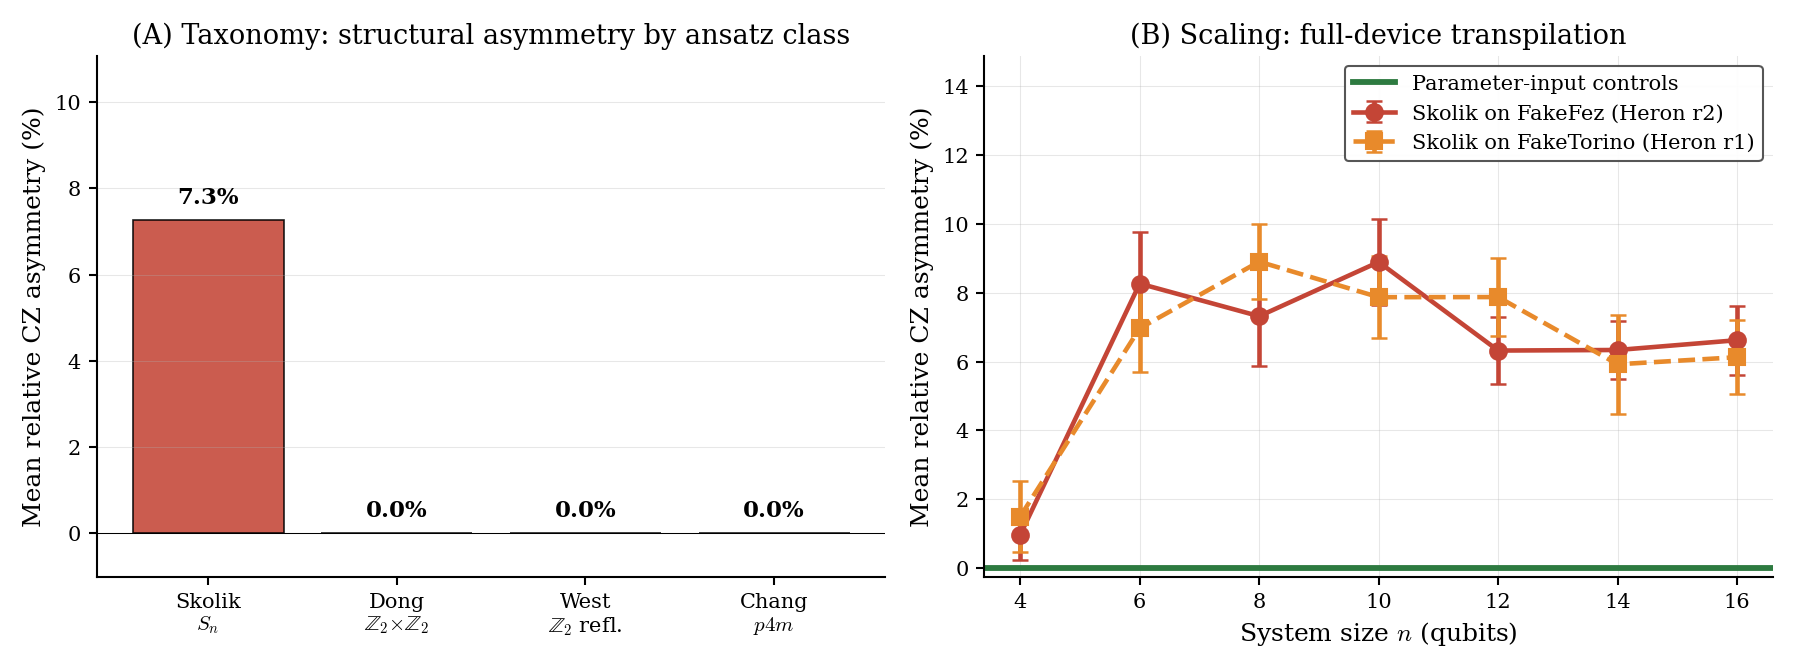

In [22]:
# Figure 1: structural asymmetry by ansatz class + scaling on both devices
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: bar chart of mean relative asymmetry by ansatz class
ax = axes[0]
labels = ['Skolik\n$S_n$', 'Dong\n$\\mathbb{Z}_2{\\times}\\mathbb{Z}_2$',
          'West\n$\\mathbb{Z}_2$ refl.', 'Chang\n$p4m$']
vals = [fez12_mean_rel * 100, 0.0, 0.0, 0.0]
types = ['topology', 'parameter', 'parameter', 'parameter']
colors = [COLOR_TOPOLOGY if t == 'topology' else COLOR_PARAMETER for t in types]

bars = ax.bar(labels, vals, color=colors, alpha=0.88,
              edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean relative CZ asymmetry (%)')
ax.set_title('(A) Taxonomy: structural asymmetry by ansatz class')
ax.set_ylim(-1, max(vals) * 1.25 + 2)
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel B: Skolik scaling on both devices, with error bars
ax = axes[1]
for backend_name, color, marker, linestyle in [
    ('FakeFez', COLOR_TOPOLOGY, 'o', '-'),
    ('FakeTorino', COLOR_ACCENT, 's', '--'),
]:
    sub = skolik_scaling[skolik_scaling['backend'] == backend_name]
    ax.errorbar(sub['n'].values, sub['cz_rel_mean'].values * 100,
                 yerr=sub['cz_rel_sem'].values * 100,
                 marker=marker, color=color, linewidth=2.2,
                 markersize=8, capsize=4, capthick=1.2, linestyle=linestyle,
                 label=f'Skolik on {backend_name} ({"Heron r2" if backend_name=="FakeFez" else "Heron r1"})')
ax.axhline(0, color=COLOR_PARAMETER, linewidth=2.8,
            label='Parameter-input controls')
ax.set_xlabel('System size $n$ (qubits)')
ax.set_ylabel('Mean relative CZ asymmetry (%)')
ax.set_title('(B) Scaling: full-device transpilation')
# Extend the upper y-limit so the legend has clean space above the
# data peaks and does not sit on the green parameter-input baseline.
ymin_b, ymax_b = ax.get_ylim()
ax.set_ylim(ymin_b, ymax_b * 1.40)
ax.legend(loc='upper right', frameon=True, framealpha=0.95)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xticks(N_RANGE)

plt.tight_layout()
save_fig('fig1_taxonomy', fig)
plt.show()

### Figure 2: Mechanism (histogram + layout-overlap scatter)

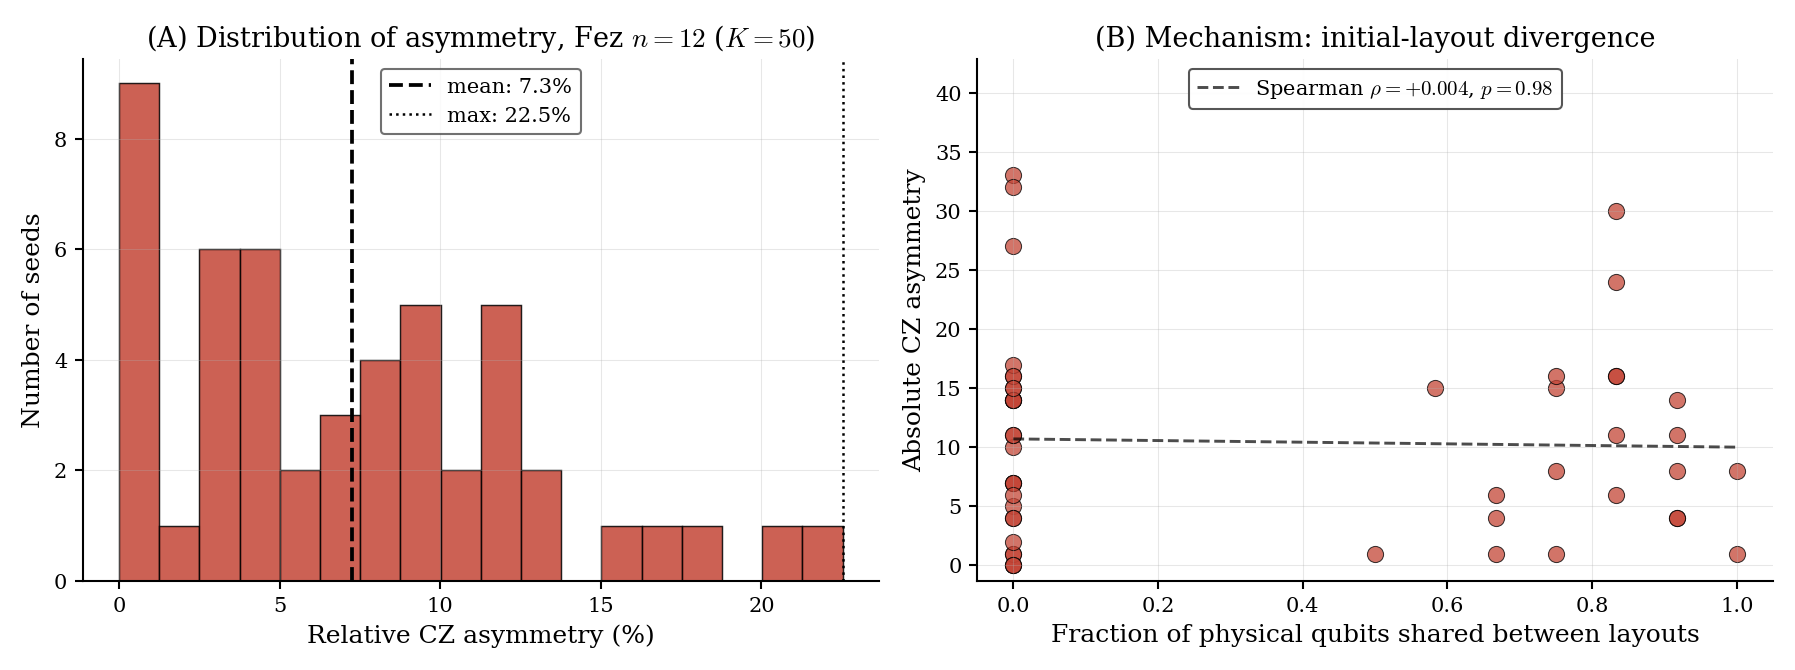

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: histogram of per-seed relative asymmetry at Fez n=12
ax = axes[0]
ax.hist(fez12_df['cz_rel'].values * 100, bins=18,
         color=COLOR_TOPOLOGY, alpha=0.85,
         edgecolor='black', linewidth=0.7)
ax.axvline(fez12_mean_rel * 100, color='black', linewidth=1.8,
            linestyle='--', label=f'mean: {fez12_mean_rel*100:.1f}%')
ax.axvline(fez12_max_rel * 100, color='black', linewidth=1.2,
            linestyle=':', label=f'max: {fez12_max_rel*100:.1f}%')
ax.set_xlabel('Relative CZ asymmetry (%)')
ax.set_ylabel('Number of seeds')
ax.set_title(f'(A) Distribution of asymmetry, Fez $n=12$ ($K = {K_MECHANISM}$)')
ax.legend(frameon=True)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel B: scatter of layout overlap vs cz_diff
ax = axes[1]
overlaps_plot = fez12_df['layout_overlap'].values
czd_plot = fez12_df['cz_diff'].values
ax.scatter(overlaps_plot, czd_plot, s=60, alpha=0.75,
            color=COLOR_TOPOLOGY, edgecolor='black', linewidth=0.5)
# Best-fit line
valid = ~np.isnan(overlaps_plot)
if valid.sum() > 2:
    slope, intercept = np.polyfit(overlaps_plot[valid], czd_plot[valid], 1)
    xfit = np.linspace(0, 1, 50)
    # Format p-value adaptively so the label is correct in any regime.
    if p_overlap < 1e-3:
        p_label = r'$p < 10^{-3}$'
    elif p_overlap < 0.01:
        p_label = f'$p = {p_overlap:.1e}$'
    else:
        p_label = f'$p = {p_overlap:.2f}$'
    ax.plot(xfit, slope * xfit + intercept, color='black',
             linestyle='--', linewidth=1.4, alpha=0.7,
             label=f'Spearman $\\rho = {rho_overlap:+.3f}$, ' + p_label)
ax.set_xlabel('Fraction of physical qubits shared between layouts')
ax.set_ylabel('Absolute CZ asymmetry')
ax.set_title('(B) Mechanism: initial-layout divergence')
# Add 30% headroom so the legend has clean space above the data points.
y_max_obs = float(np.nanmax(czd_plot)) if czd_plot.size and not np.all(np.isnan(czd_plot)) else 1.0
ax.set_ylim(-y_max_obs * 0.04, y_max_obs * 1.30)
ax.legend(frameon=True, loc='upper center', framealpha=0.95)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
save_fig('fig2_mechanism', fig)
plt.show()

### Figure 3: Mitigation (strategies comparison + compile-cost scaling)

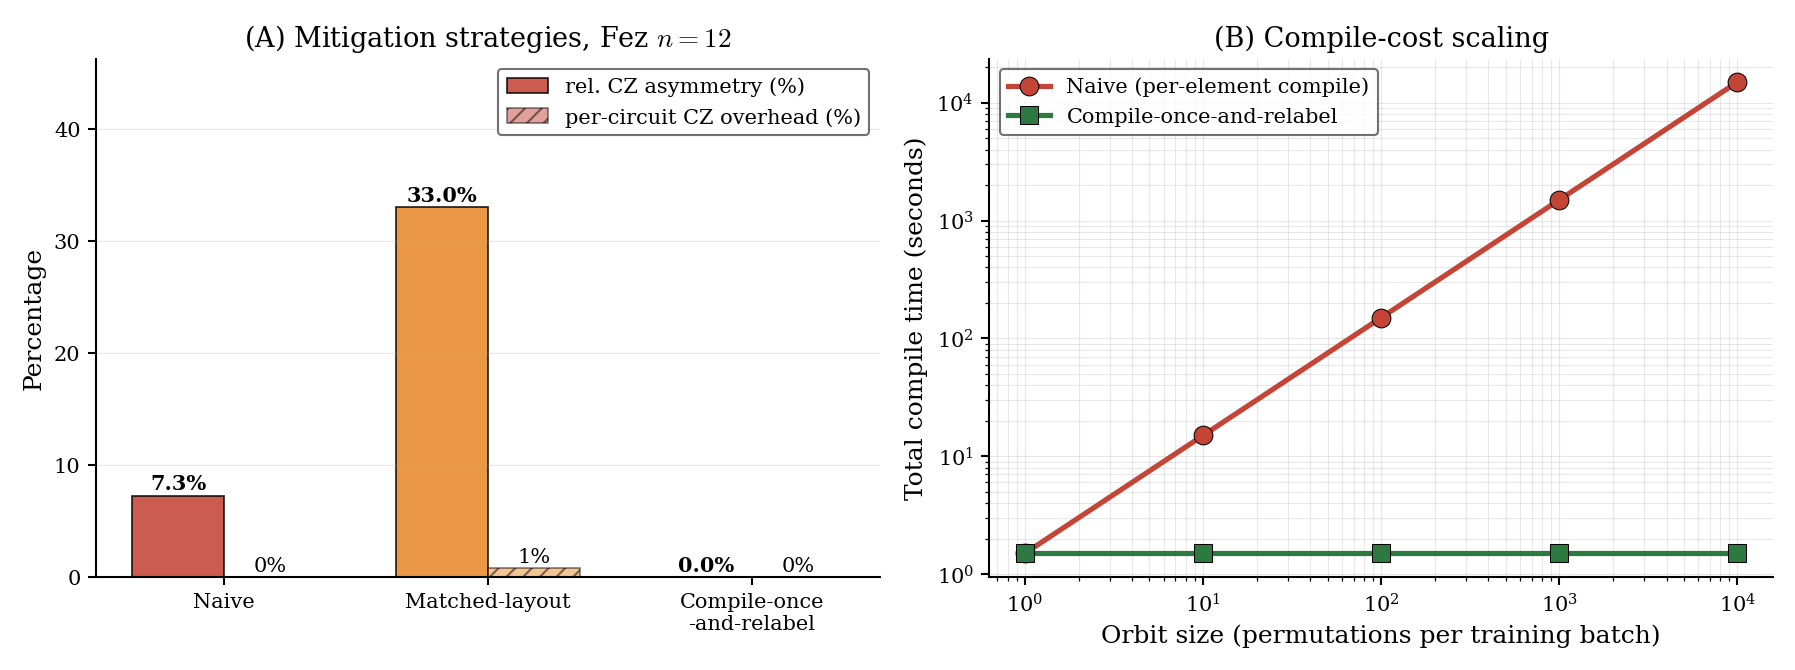

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: three strategies compared
ax = axes[0]
strategies = ['Naive', 'Matched-layout', 'Compile-once\n-and-relabel']
asym_vals = [fez12_mean_rel * 100,
             100 * matched_df['cz_diff_matched'].mean() / matched_cz_G
             if matched_cz_G > 0 else 0.0,
             0.0]
overhead_vals = [0.0,
                 matched_overhead * 100,
                 0.0]
colors_3 = [COLOR_TOPOLOGY, COLOR_ACCENT, COLOR_PARAMETER]

x = np.arange(len(strategies))
width = 0.35
bars1 = ax.bar(x - width/2, asym_vals, width,
                color=colors_3, alpha=0.88, edgecolor='black', linewidth=0.8,
                label='rel. CZ asymmetry (%)')
bars2 = ax.bar(x + width/2, overhead_vals, width,
                color=colors_3, alpha=0.5, edgecolor='black', linewidth=0.8,
                hatch='///', label='per-circuit CZ overhead (%)')
for bar, v in zip(bars1, asym_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar, v in zip(bars2, overhead_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.0f}%', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(strategies)
ax.set_ylabel('Percentage')
ax.set_ylim(0, max(max(asym_vals), max(overhead_vals)) * 1.25 + 5)
ax.set_title('(A) Mitigation strategies, Fez $n=12$')
ax.legend(frameon=True, loc='upper right')
ax.grid(alpha=0.3, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel B: compile-cost scaling
ax = axes[1]
orbit_sizes = np.array([1, 10, 100, 1000, 10000])
t_compile = 1.5  # seconds per Fez n=12 compile
naive_times = orbit_sizes * t_compile
once_times = np.full_like(orbit_sizes, t_compile, dtype=float)
ax.loglog(orbit_sizes, naive_times, marker='o',
           color=COLOR_TOPOLOGY, linewidth=2.5, markersize=9,
           markeredgecolor='black', markeredgewidth=0.5,
           label='Naive (per-element compile)')
ax.loglog(orbit_sizes, once_times, marker='s',
           color=COLOR_PARAMETER, linewidth=2.5, markersize=9,
           markeredgecolor='black', markeredgewidth=0.5,
           label='Compile-once-and-relabel')
ax.set_xlabel('Orbit size (permutations per training batch)')
ax.set_ylabel('Total compile time (seconds)')
ax.set_title('(B) Compile-cost scaling')
ax.legend(frameon=True, loc='upper left')
ax.grid(alpha=0.3, which='both')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig('fig3_mitigation', fig)
plt.show()

## 9. Reproducibility summary table

Every numerical claim in the paper, in one place. The left column gives
the paper section and claim; the middle column the value reproduced in
this notebook run; the right column the cell that computed it.

In [25]:
repro_table = [
    # Template-level equivariance
    ('Abstract',   'Skolik template equivariance residual (n=6)',
     f'{results["skolik_template_residual_n6"]:.2e}',
     'Section 2.1'),

    ('§4.2',       'Dong SWAP equivariance residual',
     f'{results["dong_swap_residual"]:.2e}',
     'Section 3.1'),

    ('§4.2',       'Dong SWAP·(X⊗X) equivariance residual',
     f'{results["dong_antidiag_residual"]:.2e}',
     'Section 3.1'),

    ('§4.3',       'West reflection identity residual (n=3)',
     f'{results["west_reflection_residual"]:.2e}',
     'Section 4.1'),

    # Skolik structural asymmetry
    ('Abstract',   'Fez n=12 mean relative CZ asymmetry',
     f'{results["fez12_mean_rel"]*100:.1f}%',
     'Section 2.3'),

    ('Abstract',   'Fez n=12 worst-case relative CZ asymmetry',
     f'{results["fez12_max_rel"]*100:.1f}%',
     'Section 2.3'),

    ('§4.2',       'Fez n=12 mean cz_diff (SEM)',
     f'{results["fez12_mean_diff"]:.1f} ± {results["fez12_sem_diff"]:.2f}',
     'Section 2.3'),

    ('§4.2',       'Fez n=12 mean cz(G) baseline',
     f'{results["fez12_cz_G_mean"]:.0f}',
     'Section 2.3'),

    # Parameter-input negative controls
    ('§4.3',       'Dong max cz_diff across all seeds/depths/orbit',
     f'{results["dong_max_cz_diff"]}',
     'Section 3.2'),

    ('§4.4',       'West max cz_diff across all seeds/qubit counts',
     f'{results["west_max_cz_diff"]}',
     'Section 4.2'),

    ('§4.5',       'Chang max cz_diff across p4m orbit',
     f'{results["chang_max_cz_diff"]}',
     'Section 5.1'),

    # Mechanism
    ('§5',         'Automorphism hypothesis: rel_orbits correlation',
     f'rho = {results["automorphism_rho_rel_orbits"]:+.3f}, p = {results["automorphism_p_rel_orbits"]:.2f}',
     'Section 6.1'),

    ('Abstract',   'Layout-overlap correlation (Fez n=12)',
     f'rho = {results["layout_overlap_rho"]:+.3f}, p = {results["layout_overlap_p"]:.2e}',
     'Section 6.2'),

    # Mitigation
    ('§6',         'Matched-layout mean cz(G)',
     f'{results["matched_cz_G"]:.1f}',
     'Section 7.1'),

    ('§6',         'Matched-layout max cz_diff',
     f'{results["matched_max_diff"]}',
     'Section 7.1'),

    ('§6',         'Matched-layout per-circuit overhead',
     f'{results["matched_overhead"]*100:+.1f}%',
     'Section 7.1'),

    ('§6',         'Compile-once unitary verification (n=8)',
     f'{results["compile_once_residual_n8"]:.2e}',
     'Section 7.2'),
]

repro_df = pd.DataFrame(repro_table, columns=['Paper loc.', 'Claim', 'Value', 'Cell'])

print("Paper 1 Reproducibility Summary")
print("=" * 100)
print(f"QUICK_MODE = {QUICK_MODE} (K_scaling={K_SCALING}, K_mechanism={K_MECHANISM})")
print(f"MASTER_SEED = {MASTER_SEED}")
print(f"Qiskit version: {qiskit.__version__}")
print("=" * 100)

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.width', 160)
print(repro_df.to_string(index=False))
print("\nAll paper numbers traceable. Run with QUICK_MODE=False for paper-quality statistics.")

Paper 1 Reproducibility Summary
QUICK_MODE = False (K_scaling=25, K_mechanism=50)
MASTER_SEED = 2026
Qiskit version: 2.4.1
Paper loc.                                           Claim                      Value        Cell
  Abstract     Skolik template equivariance residual (n=6)                   2.20e-16 Section 2.1
      §4.2                 Dong SWAP equivariance residual                   6.32e-16 Section 3.1
      §4.2           Dong SWAP·(X⊗X) equivariance residual                   6.32e-16 Section 3.1
      §4.3         West reflection identity residual (n=3)                   0.00e+00 Section 4.1
  Abstract             Fez n=12 mean relative CZ asymmetry                       7.3% Section 2.3
  Abstract       Fez n=12 worst-case relative CZ asymmetry                      22.5% Section 2.3
      §4.2                     Fez n=12 mean cz_diff (SEM)                10.5 ± 1.19 Section 2.3
      §4.2                    Fez n=12 mean cz(G) baseline                        147 Section



## License

Released under the MIT License. See `LICENSE` in the repository root.

